# Donor Lapse Classifier

This notebook builds a **predictive donor lapse classification pipeline** for the INTEX project.  
The notebook is intentionally self-contained and follows the required course structure:

1. Problem Framing  
2. Data Acquisition, Preparation & Exploration  
3. Modeling & Feature Selection  
4. Evaluation & Interpretation  
5. Causal and Relationship Analysis  
6. Deployment Notes

The pipeline predicts whether a supporter will **lapse within 180 days**, where:

- `lapsed_180d = 1` → no donation occurs within 180 days after a reference date
- `lapsed_180d = 0` → at least one donation occurs within 180 days after a reference date

This notebook uses:
- **one-hot / dummy encoding** for categorical variables
- **feature selection** inside a modeling pipeline to reduce noise and improve generalization
- **cross-validation** for reliable model comparison
- **interpretable baseline modeling** plus a stronger tree-based model
- **error handling** and clear comments throughout

## 1. Problem Framing

### Business problem
The organization depends heavily on donor retention and recurring support. A donor lapse model helps fundraising staff identify supporters who are at risk of **not donating again within the next 180 days**, so the team can prioritize outreach, stewardship, and re-engagement.

### Who cares
- Fundraising and donor-relations staff
- Leadership monitoring donor health
- Communications staff coordinating campaigns and stewardship
- Product / web-app team integrating donor risk into internal dashboards

### Why it matters
A donor who lapses may represent lost recurring revenue, reduced campaign momentum, and weaker long-term support. A reliable lapse-risk score can support:
- targeted outreach lists
- risk-tier dashboards
- stewardship recommendations
- future donor-growth experiments

### Predictive vs explanatory framing
This notebook is **primarily predictive** because the organization needs an operational score that can be deployed in the website.  
However, the notebook also includes a **relationship / explanatory analysis** section to interpret which donor patterns are associated with lapse risk.

### Deployment goal
The final output is a supporter-level scored table with:
- `supporter_id`
- predicted lapse probability
- risk tier (`High`, `Medium`, `Low`)
- outreach recommendation

## 2. Data Acquisition, Preparation & Exploration

### Relevant tables
This pipeline uses the donor/support domain tables:

- `supporters.csv`
- `donations.csv`
- `donation_allocations.csv`

### Join logic
- `supporters` is the entity table
- `donations` contains donor behavior over time
- `donation_allocations` adds stewardship / program-area behavior

### Modeling grain
The final modeling table is built at the **supporter snapshot** level:
- one row per supporter per eligible reference date

This is more appropriate than donation-level modeling because the business question is about **supporter lapse risk**, not whether a specific donation record will be followed by another.

### Leakage rule
Features are created using data available **on or before the reference date only**.  
The target looks **forward 180 days** from the reference date.  
This separation is critical to avoid leakage.

In [2]:

# Imports and configuration

from __future__ import annotations

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

SEED = 27
PREDICTION_WINDOW_DAYS = 180

# Adjust this path if needed.
# This notebook assumes the CSV files live in:
#   ./lighthouse_csv_v7/
DATA_DIR = Path("../lighthouse_csv_v7/lighthouse_csv_v7")

REQUIRED_FILES = {
    "supporters": DATA_DIR / "supporters.csv",
    "donations": DATA_DIR / "donations.csv",
    "donation_allocations": DATA_DIR / "donation_allocations.csv",
}

print("Configured data directory:", DATA_DIR.resolve())

Configured data directory: C:\Users\Ashns\OneDrive\INTEX26\INTEX_W2026\lighthouse_csv_v7\lighthouse_csv_v7


In [3]:

# Helper functions: loading and checking

def assert_required_files_exist(required_files: Dict[str, Path]) -> None:
    """Raise a clear error if any required CSV file is missing."""
    missing = [name for name, path in required_files.items() if not path.exists()]
    if missing:
        missing_str = ", ".join(missing)
        raise FileNotFoundError(
            f"Missing required CSV files: {missing_str}. "
            f"Expected them under: {DATA_DIR.resolve()}"
        )


def load_csv_safe(path: Path, parse_dates: Optional[List[str]] = None) -> pd.DataFrame:
    """Load a CSV file with basic error handling and optional date parsing."""
    try:
        # Read the CSV file from the specified path
        df = pd.read_csv(path)
    except Exception as exc:
        # If file cannot be read, raise a descriptive error with the file path
        raise RuntimeError(f"Failed to read CSV: {path}") from exc
    
    # If date columns are specified, convert them to datetime format
    if parse_dates:
        for col in parse_dates:
            if col in df.columns:
                # Convert column to datetime, coercing errors to NaT (Not a Time)
                df[col] = pd.to_datetime(df[col], errors="coerce")
    
    return df


def validate_required_columns(df: pd.DataFrame, table_name: str, required_cols: List[str]) -> None:
    """Ensure key columns exist before pipeline logic continues."""
    # Check which required columns are missing from the dataframe
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        # Raise an error listing the missing columns for the specific table
        raise ValueError(
            f"Table '{table_name}' is missing required columns: {missing}"
        )


# Verify that all required CSV files exist before proceeding
assert_required_files_exist(REQUIRED_FILES)

# Load the supporters CSV with date parsing for created_at and first_donation_date
supporters = load_csv_safe(
    REQUIRED_FILES["supporters"],
    parse_dates=["created_at", "first_donation_date"]
)

# Load the donations CSV with date parsing for donation_date
donations = load_csv_safe(
    REQUIRED_FILES["donations"],
    parse_dates=["donation_date"]
)

# Load the donation_allocations CSV with date parsing for allocation_date
allocations = load_csv_safe(
    REQUIRED_FILES["donation_allocations"],
    parse_dates=["allocation_date"]
)

# Validate that the supporters table has all required columns
validate_required_columns(
    supporters,
    "supporters",
    ["supporter_id", "supporter_type", "created_at"]
)

# Validate that the donations table has all required columns
validate_required_columns(
    donations,
    "donations",
    [
        "donation_id",
        "supporter_id",
        "donation_date",
        "donation_type",
        "estimated_value",
        "channel_source",
        "is_recurring"
    ]
)

# Validate that the allocations table has all required columns
validate_required_columns(
    allocations,
    "donation_allocations",
    ["allocation_id", "donation_id", "safehouse_id", "program_area", "amount_allocated"]
)

# Print the shape (rows, columns) of each loaded dataframe for verification
print("supporters shape:", supporters.shape)
print("donations shape:", donations.shape)
print("allocations shape:", allocations.shape)

supporters shape: (60, 15)
donations shape: (420, 13)
allocations shape: (521, 7)


In [4]:

# Quick structural overview / QC check
print("\n--- Supporters info ---")
display(supporters.head())
display(supporters.info())

print("\n--- Donations info ---")
display(donations.head())
display(donations.info())

print("\n--- Allocations info ---")
display(allocations.head())
display(allocations.info())


--- Supporters info ---


,supporter_id,supporter_type,display_name,organization_name,first_name,last_name,relationship_type,region,country,email,phone,status,created_at,first_donation_date,acquisition_channel
0,1,SocialMediaAdvocate,Mila Alvarez,NaN,Mila,Alvarez,Local,Luzon,Philippines,mila-alvarez@smart.com.ph,+63 997 578 1887,Active,2022-01-01,2023-07-02,SocialMedia
1,2,Volunteer,Aria Brown,NaN,Aria,Brown,Local,Mindanao,Philippines,aria-brown@pldt.net.ph,+63 927 354 4139,Active,2022-01-06,2023-09-25,SocialMedia
2,3,MonetaryDonor,Noah Chen,NaN,Noah,Chen,Local,Luzon,Philippines,noah-chen@globe.com.ph,+63 917 553 2604,Active,2022-01-11,2023-06-25,SocialMedia
3,4,MonetaryDonor,Liam Diaz,NaN,Liam,Diaz,PartnerOrganization,Mindanao,Philippines,liam-diaz@globe.com.ph,+63 945 516 8956,Active,2022-01-16,2026-03-01,Church
4,5,InKindDonor,Emma Evans,NaN,Emma,Evans,PartnerOrganization,Mindanao,Philippines,emma-evans@yahoo.com.ph,+63 995 371 8454,Active,2022-01-21,2024-01-18,Website


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   supporter_id         60 non-null     int64         
 1   supporter_type       60 non-null     object        
 2   display_name         60 non-null     object        
 3   organization_name    4 non-null      object        
 4   first_name           56 non-null     object        
 5   last_name            56 non-null     object        
 6   relationship_type    60 non-null     object        
 7   region               60 non-null     object        
 8   country              60 non-null     object        
 9   email                60 non-null     object        
 10  phone                60 non-null     object        
 11  status               60 non-null     object        
 12  created_at           60 non-null     datetime64[ns]
 13  first_donation_date  59 non-null     

None


--- Donations info ---


...

None


--- Allocations info ---


,allocation_id,donation_id,safehouse_id,program_area,amount_allocated,allocation_date,allocation_notes
0,1,1,2,Education,717.18,2025-12-31,NaN
1,2,2,4,Transport,35.15,2025-12-02,NaN
2,3,3,8,Wellbeing,1074.65,2024-12-02,NaN
3,4,4,9,Operations,799.86,2023-09-11,NaN
4,5,5,8,Operations,1177.41,2023-11-08,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   allocation_id     521 non-null    int64         
 1   donation_id       521 non-null    int64         
 2   safehouse_id      521 non-null    int64         
 3   program_area      521 non-null    object        
 4   amount_allocated  521 non-null    float64       
 5   allocation_date   521 non-null    datetime64[ns]
 6   allocation_notes  0 non-null      float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(1)
memory usage: 28.6+ KB


None

In [ ]:

# Basic data quality and missingness inspection

def missingness_table(df: pd.DataFrame, table_name: str) -> pd.DataFrame:
    out = (
        df.isna()
          .mean()
          .rename("missing_pct")
          .reset_index()
          .rename(columns={"index": "column"})
          .sort_values("missing_pct", ascending=False)
    )
    # Add a column identifying which table this data came from
    out["table"] = table_name
    return out[["table", "column", "missing_pct"]]

# Combine missingness summaries from all three tables into one dataframe
missing_summary = pd.concat(
    [
        missingness_table(supporters, "supporters"),
        missingness_table(donations, "donations"),
        missingness_table(allocations, "donation_allocations")
    ],
    ignore_index=True
)

display(missing_summary.head(20))

,table,column,missing_pct
0,supporters,organization_name,0.933333
1,supporters,first_name,0.066667
2,supporters,last_name,0.066667
3,supporters,first_donation_date,0.016667
4,supporters,display_name,0.000000
5,supporters,supporter_id,0.000000
6,supporters,supporter_type,0.000000
7,supporters,relationship_type,0.000000
8,supporters,region,0.000000
9,supporters,email,0.000000


### Notes on data quality
Expected structural missingness may appear in donor tables:
- `organization_name` is likely blank for individual supporters
- `amount` may be blank for non-monetary donations
- `referral_post_id` may be blank when a donation did not come from a social post

Those are not automatically treated as data errors.

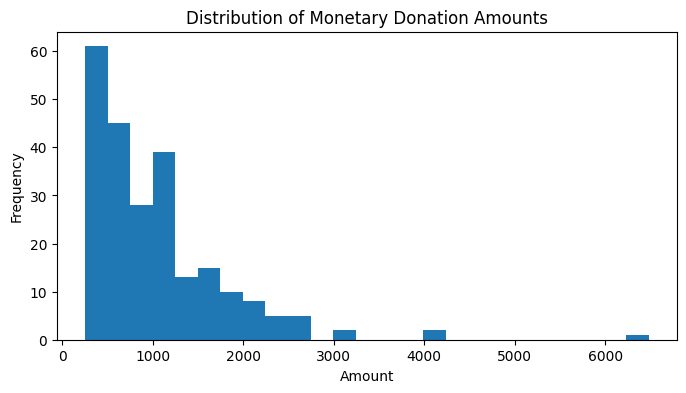

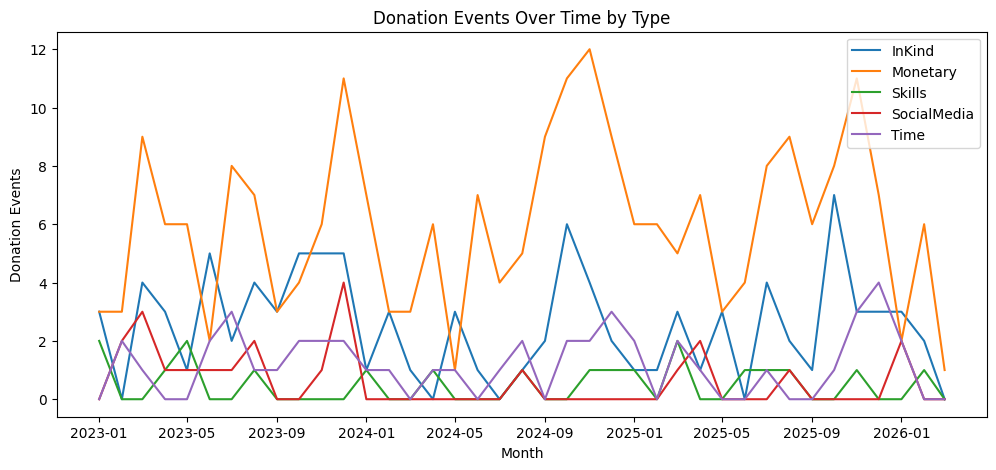

,count,mean,std,min,25%,50%,75%,max
donation_events,59.0,7.118644,4.514669,1.00,4.00,6.00,9.00,23.00
total_estimated_value,59.0,4978.098475,3542.859192,27.12,2211.99,3976.01,6951.16,14240.29
days_since_last_donation,59.0,185.542373,186.852452,0.00,59.50,118.00,267.50,797.00


In [ ]:

# Donation EDA snapshots

# Donation amount distribution
monetary_amounts = donations.loc[
    (donations["donation_type"].astype(str).str.lower() == "monetary") & donations["amount"].notna(),
    "amount"
].copy()

plt.figure(figsize=(8, 4))
plt.hist(monetary_amounts, bins=25)
plt.title("Distribution of Monetary Donation Amounts")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

# Donation events by month and type
donations["donation_month"] = donations["donation_date"].dt.to_period("M").dt.to_timestamp()
monthly_counts = (
    donations.groupby(["donation_month", "donation_type"])
             .size()
             .reset_index(name="events")
)

pivot_monthly = monthly_counts.pivot(index="donation_month", columns="donation_type", values="events").fillna(0)

plt.figure(figsize=(12, 5))
for col in pivot_monthly.columns:
    plt.plot(pivot_monthly.index, pivot_monthly[col], label=str(col))
plt.title("Donation Events Over Time by Type")
plt.xlabel("Month")
plt.ylabel("Donation Events")
plt.legend()
plt.show()

# Supporter-level quick summary using historical full data
supporter_hist = (
    donations.groupby("supporter_id")
    .agg(
        donation_events=("donation_id", "count"),
        total_estimated_value=("estimated_value", "sum"),
        first_seen_donation=("donation_date", "min"),
        last_seen_donation=("donation_date", "max")
    )
    .reset_index()
)

analysis_end = donations["donation_date"].max()
supporter_hist["days_since_last_donation"] = (analysis_end - supporter_hist["last_seen_donation"]).dt.days

display(supporter_hist[["donation_events", "total_estimated_value", "days_since_last_donation"]].describe().T)

### EDA takeaways for modeling
The donor data typically supports strong retention-style features:
- **recency**: days since last donation
- **frequency**: donation counts over multiple lookback windows
- **monetary**: total, average, and max giving
- **behavioral mix**: donation types, channel source, recurring share
- **stewardship / allocation behavior**: number of funded program areas

These features are consistent with standard donor-retention logic and should be useful for a lapse model.

## Build a Reproducible Feature Pipeline

The next section creates a supporter-snapshot modeling dataset.  
Each snapshot uses only donor history available **on or before the reference date**, then labels the snapshot based on whether another donation occurs within the next 180 days.

In [ ]:

# Feature engineering helpers for supporter snapshot records

def coerce_bool_series(series: pd.Series) -> pd.Series:
    """Convert mixed boolean-like values to integers 0/1 safely."""
    return (
        series.astype(str)
              .str.strip()
              .str.lower()
              .map({"true": 1, "false": 0, "1": 1, "0": 0})
              .fillna(0)
              .astype(int)
    )


def prepare_base_tables(
    supporters_df: pd.DataFrame,
    donations_df: pd.DataFrame,
    allocations_df: pd.DataFrame
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Apply lightweight standardization to base tables."""
    supporters_clean = supporters_df.copy()
    donations_clean = donations_df.copy()
    allocations_clean = allocations_df.copy()

    # Standardize recurring flag
    if "is_recurring" in donations_clean.columns:
        donations_clean["is_recurring_flag"] = coerce_bool_series(donations_clean["is_recurring"])
    else:
        donations_clean["is_recurring_flag"] = 0

    # Fill numeric contribution proxies safely
    donations_clean["estimated_value"] = pd.to_numeric(
        donations_clean["estimated_value"], errors="coerce"
    ).fillna(0.0)

    if "amount" in donations_clean.columns:
        donations_clean["amount"] = pd.to_numeric(donations_clean["amount"], errors="coerce")

    allocations_clean["amount_allocated"] = pd.to_numeric(
        allocations_clean["amount_allocated"], errors="coerce"
    ).fillna(0.0)

    return supporters_clean, donations_clean, allocations_clean


supporters_clean, donations_clean, allocations_clean = prepare_base_tables(
    supporters, donations, allocations
)

In [ ]:

# Snapshot generation

def choose_reference_dates(
    donations_df: pd.DataFrame,
    window_days: int = 180,
    min_history_days: int = 90
) -> List[pd.Timestamp]:
    """Choose monthly reference dates that allow a forward label window."""
    min_date = donations_df["donation_date"].min()
    max_date = donations_df["donation_date"].max()

    if pd.isna(min_date) or pd.isna(max_date):
        raise ValueError("Donation dates are missing or invalid.")

    start_date = (min_date + pd.Timedelta(days=min_history_days)).normalize()
    end_date = (max_date - pd.Timedelta(days=window_days)).normalize()

    if end_date <= start_date:
        raise ValueError(
            "Not enough date coverage to build snapshot labels. "
            "Reduce the history or prediction window."
        )

    reference_dates = pd.date_range(start=start_date, end=end_date, freq="MS")
    return list(reference_dates)


def build_supporter_snapshot_features(
    supporters_df: pd.DataFrame,
    donations_df: pd.DataFrame,
    allocations_df: pd.DataFrame,
    reference_date: pd.Timestamp,
    window_days: int = 180
) -> pd.DataFrame:
    """Build one supporter-level snapshot table for a single reference date."""
    hist = donations_df.loc[donations_df["donation_date"] <= reference_date].copy()
    future = donations_df.loc[
        (donations_df["donation_date"] > reference_date) &
        (donations_df["donation_date"] <= reference_date + pd.Timedelta(days=window_days))
    ].copy()

    if hist.empty:
        raise ValueError("Historical donation slice is empty for the chosen reference date.")

    hist_alloc = hist[["donation_id", "supporter_id"]].merge(
        allocations_df[["donation_id", "program_area", "amount_allocated"]],
        on="donation_id",
        how="left"
    )

    # Core donor history features
    grp = hist.groupby("supporter_id")

    base = grp.agg(
        hist_total_events=("donation_id", "count"),
        hist_total_estimated_value=("estimated_value", "sum"),
        hist_avg_estimated_value=("estimated_value", "mean"),
        hist_max_estimated_value=("estimated_value", "max"),
        hist_std_estimated_value=("estimated_value", "std"),
        first_donation_seen=("donation_date", "min"),
        last_donation_seen=("donation_date", "max"),
        recurring_events=("is_recurring_flag", "sum"),
        unique_donation_types=("donation_type", "nunique"),
        unique_channels=("channel_source", "nunique")
    ).reset_index()

    # Lookback windows
    def add_window_counts(days: int, df_out: pd.DataFrame) -> pd.DataFrame:
        cutoff = reference_date - pd.Timedelta(days=days)
        sub = hist.loc[hist["donation_date"] > cutoff].copy()

        if sub.empty:
            temp = pd.DataFrame({"supporter_id": supporters_df["supporter_id"].unique()})
            temp[f"events_last_{days}d"] = 0
            temp[f"value_last_{days}d"] = 0.0
            temp[f"monetary_events_last_{days}d"] = 0
            return df_out.merge(temp, on="supporter_id", how="left")

        sub["is_monetary"] = (
            sub["donation_type"].astype(str).str.lower().eq("monetary").astype(int)
        )

        temp = sub.groupby("supporter_id").agg(
            **{
                f"events_last_{days}d": ("donation_id", "count"),
                f"value_last_{days}d": ("estimated_value", "sum"),
                f"monetary_events_last_{days}d": ("is_monetary", "sum"),
            }
        ).reset_index()

        return df_out.merge(temp, on="supporter_id", how="left")

    for lookback in [30, 90, 180, 365]:
        base = add_window_counts(lookback, base)

    # Donation type mode
    type_mode = (
        hist.groupby(["supporter_id", "donation_type"]).size()
            .reset_index(name="n")
            .sort_values(["supporter_id", "n", "donation_type"], ascending=[True, False, True])
            .drop_duplicates("supporter_id")
            .rename(columns={"donation_type": "dominant_donation_type"})
            [["supporter_id", "dominant_donation_type"]]
    )
    base = base.merge(type_mode, on="supporter_id", how="left")

    # Channel mode
    channel_mode = (
        hist.groupby(["supporter_id", "channel_source"]).size()
            .reset_index(name="n")
            .sort_values(["supporter_id", "n", "channel_source"], ascending=[True, False, True])
            .drop_duplicates("supporter_id")
            .rename(columns={"channel_source": "dominant_channel_source"})
            [["supporter_id", "dominant_channel_source"]]
    )
    base = base.merge(channel_mode, on="supporter_id", how="left")

    # Allocation features
    alloc_features = (
        hist_alloc.groupby("supporter_id")
        .agg(
            funded_program_areas=("program_area", "nunique"),
            total_allocated=("amount_allocated", "sum")
        )
        .reset_index()
    )
    base = base.merge(alloc_features, on="supporter_id", how="left")

    # Supporter profile features
    supporter_profile_cols = [
        c for c in [
            "supporter_id",
            "supporter_type",
            "organization_name",
            "display_name",
            "created_at",
            "first_donation_date"
        ] if c in supporters_df.columns
    ]

    profile = supporters_df[supporter_profile_cols].copy()

    # Create a simple org-vs-individual proxy
    if "organization_name" in profile.columns:
        profile["is_organization"] = profile["organization_name"].notna().astype(int)
    else:
        profile["is_organization"] = 0

    profile = profile.drop(columns=[c for c in ["display_name", "organization_name"] if c in profile.columns])

    snapshot = base.merge(profile, on="supporter_id", how="left")

    # Date-derived features
    snapshot["reference_date"] = pd.Timestamp(reference_date)

    snapshot["days_since_last_donation"] = (
        snapshot["reference_date"] - snapshot["last_donation_seen"]
    ).dt.days

    snapshot["days_since_first_donation"] = (
        snapshot["reference_date"] - snapshot["first_donation_seen"]
    ).dt.days

    if "created_at" in snapshot.columns:
        snapshot["days_since_supporter_created"] = (
            snapshot["reference_date"] - snapshot["created_at"]
        ).dt.days

    snapshot["recurring_share"] = (
        snapshot["recurring_events"] / snapshot["hist_total_events"]
    ).replace([np.inf, -np.inf], np.nan)

    # Fill numeric nulls created by aggregation
    numeric_cols = snapshot.select_dtypes(include=[np.number]).columns.tolist()
    for col in numeric_cols:
        snapshot[col] = snapshot[col].fillna(0)

    # Build the label using future donations
    future_flag = (
        future.groupby("supporter_id")
              .size()
              .reset_index(name="future_events_in_window")
    )
    snapshot = snapshot.merge(future_flag, on="supporter_id", how="left")
    snapshot["future_events_in_window"] = snapshot["future_events_in_window"].fillna(0).astype(int)
    snapshot["lapsed_180d"] = (snapshot["future_events_in_window"] == 0).astype(int)

    # Keep only supporters with at least one donation historically by reference date
    snapshot = snapshot.loc[snapshot["hist_total_events"] > 0].copy()

    return snapshot


reference_dates = choose_reference_dates(
    donations_clean,
    window_days=PREDICTION_WINDOW_DAYS,
    min_history_days=90
)

print("Number of eligible reference dates:", len(reference_dates))
print("First few reference dates:", reference_dates[:5])
print("Last few reference dates:", reference_dates[-5:])

Number of eligible reference dates: 29
First few reference dates: [Timestamp('2023-05-01 00:00:00'), Timestamp('2023-06-01 00:00:00'), Timestamp('2023-07-01 00:00:00'), Timestamp('2023-08-01 00:00:00'), Timestamp('2023-09-01 00:00:00')]
Last few reference dates: [Timestamp('2025-05-01 00:00:00'), Timestamp('2025-06-01 00:00:00'), Timestamp('2025-07-01 00:00:00'), Timestamp('2025-08-01 00:00:00'), Timestamp('2025-09-01 00:00:00')]


In [ ]:

# Build full modeling dataset across dates
snapshots = []

for ref_date in reference_dates:
    try:
        snap = build_supporter_snapshot_features(
            supporters_df=supporters_clean,
            donations_df=donations_clean,
            allocations_df=allocations_clean,
            reference_date=ref_date,
            window_days=PREDICTION_WINDOW_DAYS
        )
        snapshots.append(snap)
    except Exception as exc:
        print(f"Skipping reference date {ref_date.date()} due to error: {exc}")

if not snapshots:
    raise RuntimeError("No valid snapshot datasets were created.")

model_df = pd.concat(snapshots, ignore_index=True)

print("Modeling dataset shape:", model_df.shape)
display(model_df.head())

Modeling dataset shape: (1473, 38)


,supporter_id,hist_total_events,hist_total_estimated_value,hist_avg_estimated_value,hist_max_estimated_value,hist_std_estimated_value,first_donation_seen,last_donation_seen,recurring_events,unique_donation_types,...,created_at,first_donation_date,is_organization,reference_date,days_since_last_donation,days_since_first_donation,days_since_supporter_created,recurring_share,future_events_in_window,lapsed_180d
0,1,1,774.61,774.61,774.61,0.000000,2023-03-25,2023-03-25,1,1,...,2022-01-01,2023-07-02,0,2023-05-01,37,37,485,1.0,4,0
1,2,1,2565.03,2565.03,2565.03,0.000000,2023-03-08,2023-03-08,0,1,...,2022-01-06,2023-09-25,0,2023-05-01,54,54,480,0.0,2,0
2,3,2,550.00,275.00,300.00,35.355339,2023-02-22,2023-04-09,2,2,...,2022-01-11,2023-06-25,0,2023-05-01,22,68,475,1.0,2,0
3,4,1,439.51,439.51,439.51,0.000000,2023-03-15,2023-03-15,1,1,...,2022-01-16,2026-03-01,0,2023-05-01,47,47,470,1.0,0,1
4,6,1,11.87,11.87,11.87,0.000000,2023-03-22,2023-03-22,0,1,...,2022-01-26,2023-03-22,0,2023-05-01,40,40,460,0.0,2,0


In [ ]:

# Quick target and feature inspection

target_rate = model_df["lapsed_180d"].mean()
print(f"Lapse rate in modeling dataset: {target_rate:.3f}")

display(model_df["lapsed_180d"].value_counts(dropna=False))

# Check for duplicate supporter-reference rows
dup_count = model_df.duplicated(subset=["supporter_id", "reference_date"]).sum()
print("Duplicate supporter-reference rows:", dup_count)

Lapse rate in modeling dataset: 0.371


lapsed_180d
0    926
1    547
Name: count, dtype: int64

Duplicate supporter-reference rows: 0


### Feature engineering summary
This modeling table includes:
- **recency** features
- **frequency** features across multiple lookback windows
- **monetary/value** features
- **allocation / stewardship** features
- **donation mix** features
- **supporter profile** features

This follows the course expectation that preparation be a **reproducible pipeline**, not a one-off manual script.

## 3. Modeling & Feature Selection

### Modeling plan
Two models are compared:

1. **Logistic Regression**
   - interpretable baseline
   - works well with one-hot / dummy coding
   - useful for relationship interpretation

2. **Random Forest Classifier**
   - stronger nonlinear model
   - handles interactions and nonlinearity better
   - useful if donor behavior is not linearly separable

### Feature selection plan
Feature selection is built directly into the modeling workflow:
- categorical variables are dummy-coded with `OneHotEncoder`
- numeric values are imputed and scaled where appropriate
- a **model-based selector** keeps only features with meaningful signal before the final classifier

This is done inside the pipeline to reduce leakage risk.

In [ ]:

# Train / test split with time-aware logic

# A simple time-based holdout is more realistic for deployment.
# Earlier reference dates go to training, later ones go to testing.

model_df = model_df.sort_values("reference_date").reset_index(drop=True)

cutoff_date = model_df["reference_date"].quantile(0.80)
train_df = model_df.loc[model_df["reference_date"] <= cutoff_date].copy()
test_df = model_df.loc[model_df["reference_date"] > cutoff_date].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Train date range:", train_df["reference_date"].min(), "to", train_df["reference_date"].max())
print("Test date range:", test_df["reference_date"].min(), "to", test_df["reference_date"].max())

Train shape: (1178, 38)
Test shape: (295, 38)
Train date range: 2023-05-01 00:00:00 to 2025-04-01 00:00:00
Test date range: 2025-05-01 00:00:00 to 2025-09-01 00:00:00


In [ ]:

# Define X / y and exclude leakage fields

TARGET = "lapsed_180d"

drop_cols = [
    TARGET,
    "future_events_in_window",      # direct forward-looking label component
    "reference_date",               # used for splitting, not modeling
    "supporter_id",                 # identifier only
    "first_donation_seen",          # raw date retained only for feature creation
    "last_donation_seen",           # raw date retained only for feature creation
    "created_at",                   # raw date retained only for feature creation
    "first_donation_date",          # raw supporter date retained only for feature creation
]

feature_cols = [c for c in model_df.columns if c not in drop_cols]

X_train = train_df[feature_cols].copy()
y_train = train_df[TARGET].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[TARGET].copy()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Number of features before encoding:", len(feature_cols))

X_train shape: (1178, 30)
X_test shape: (295, 30)
Number of features before encoding: 30


In [ ]:

# Identify numeric and categorical fields

numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("\nCategorical columns:", categorical_cols)

Numeric columns: ['hist_total_events', 'hist_total_estimated_value', 'hist_avg_estimated_value', 'hist_max_estimated_value', 'hist_std_estimated_value', 'recurring_events', 'unique_donation_types', 'unique_channels', 'events_last_30d', 'value_last_30d', 'monetary_events_last_30d', 'events_last_90d', 'value_last_90d', 'monetary_events_last_90d', 'events_last_180d', 'value_last_180d', 'monetary_events_last_180d', 'events_last_365d', 'value_last_365d', 'monetary_events_last_365d', 'funded_program_areas', 'total_allocated', 'is_organization', 'days_since_last_donation', 'days_since_first_donation', 'days_since_supporter_created', 'recurring_share']

Categorical columns: ['dominant_donation_type', 'dominant_channel_source', 'supporter_type']


In [ ]:

# Build preprocessing and model pipelines

numeric_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_cols),
        ("cat", categorical_pipe, categorical_cols)
    ],
    remainder="drop"
)

# Logistic regression baseline
logit_pipe = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("select", SelectFromModel(
            LogisticRegression(
                penalty="l1",
                solver="liblinear",
                random_state=SEED,
                max_iter=2000
            ),
            threshold="median"
        )),
        ("model", LogisticRegression(
            solver="liblinear",
            random_state=SEED,
            max_iter=2000
        ))
    ]
)

# Random forest model
rf_pipe = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("select", SelectFromModel(
            LogisticRegression(
                penalty="l1",
                solver="liblinear",
                random_state=SEED,
                max_iter=2000
            ),
            threshold="median"
        )),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=SEED,
            class_weight="balanced",
            max_depth=None,
            min_samples_leaf=2
        ))
    ]
)

In [ ]:

# Cross-validation model comparison

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Define the scoring metrics to evaluate model performance
scoring = {
    "roc_auc": "roc_auc",
    "avg_precision": "average_precision",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall"
}

# Define the models to compare
models = {
    "LogisticRegression": logit_pipe,
    "RandomForest": rf_pipe
}

# Initialize empty list to store cross-validation results
cv_results = []

# Loop through each model and evaluate using cross-validation
for model_name, pipe in models.items():
    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        error_score="raise"
    )
    # Create a dictionary to store this model's results
    row = {"model": model_name}
    for metric_name, values in scores.items():
        if metric_name.startswith("test_"):
            clean_name = metric_name.replace("test_", "")
            row[f"{clean_name}_mean"] = np.mean(values)
            row[f"{clean_name}_std"] = np.std(values)

    # Add this model's results to the results list
    cv_results.append(row)

cv_results_df = pd.DataFrame(cv_results).sort_values("roc_auc_mean", ascending=False)
display(cv_results_df)

,model,roc_auc_mean,roc_auc_std,avg_precision_mean,avg_precision_std,f1_mean,f1_std,precision_mean,precision_std,recall_mean,recall_std
1,RandomForest,0.950734,0.015982,0.934676,0.025605,0.848746,0.037877,0.850761,0.025268,0.847566,0.054295
0,LogisticRegression,0.747646,0.022962,0.628231,0.030993,0.562597,0.050210,0.611282,0.049397,0.522297,0.055325


In [ ]:

# Tune the stronger model if desired

rf_param_grid = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [None, 4, 6, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

rf_search = GridSearchCV(
    estimator=rf_pipe,
    param_grid=rf_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True
)

rf_search.fit(X_train, y_train)

print("Best RF params:", rf_search.best_params_)
print("Best RF CV ROC AUC:", rf_search.best_score_)
best_model = rf_search.best_estimator_

Best RF params: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 300}
Best RF CV ROC AUC: 0.9656035892372443


## 4. Evaluation & Interpretation

The model is evaluated on a holdout period that comes **after** the training period.  
This is a stronger test of deployment realism than a purely random split because it better mimics scoring future supporter snapshots.

In [ ]:

# Final holdout evaluation
def evaluate_classifier(model, X, y, label: str = "Model") -> pd.DataFrame:
    """Return a compact evaluation table and print useful details."""
    proba = model.predict_proba(X)[:, 1]

    # Get binary predictions using 0.50 threshold and convert to integer
    pred = (proba >= 0.50).astype(int)

     # Calculate all evaluation metrics and store in a dictionary
    metrics = {
        "model": label,
        "roc_auc": roc_auc_score(y, proba),
        "avg_precision": average_precision_score(y, proba),
        "f1": f1_score(y, pred, zero_division=0),
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred, zero_division=0),
    }

    print(f"\n=== {label} ===")
    print(pd.DataFrame([metrics]))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y, pred))
    print("\nClassification Report:")
    print(classification_report(y, pred, zero_division=0))

    return pd.DataFrame([metrics]), proba, pred

# Evaluate the best model (Random Forest) on the holdout test set
eval_df, test_proba, test_pred = evaluate_classifier(
    best_model,
    X_test,
    y_test,
    label="Best Random Forest Pipeline"
)

display(eval_df)


=== Best Random Forest Pipeline ===
                         model  roc_auc  avg_precision        f1  precision  \
0  Best Random Forest Pipeline   0.6921       0.470799  0.506667   0.459677   

     recall  
0  0.564356  

Confusion Matrix:
[[127  67]
 [ 44  57]]

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.65      0.70       194
           1       0.46      0.56      0.51       101

    accuracy                           0.62       295
   macro avg       0.60      0.61      0.60       295
weighted avg       0.65      0.62      0.63       295



,model,roc_auc,avg_precision,f1,precision,recall
0,Best Random Forest Pipeline,0.6921,0.470799,0.506667,0.459677,0.564356


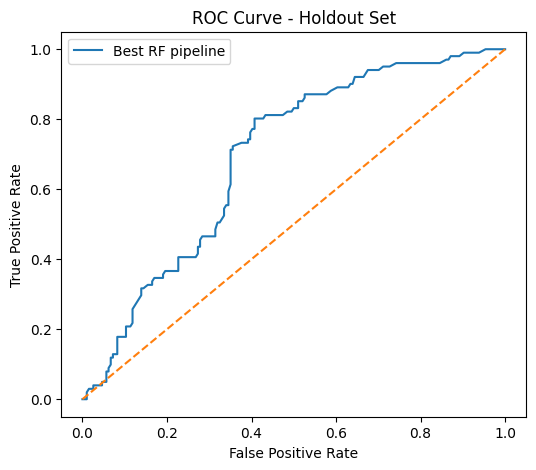

In [ ]:

# ROC curve on the holdout set

fpr, tpr, _ = roc_curve(y_test, test_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label="Best RF pipeline")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Holdout Set")
plt.legend()
plt.show()

### Business interpretation of errors

#### False positive
A supporter is predicted to lapse, but they would have donated anyway.
- Cost: unnecessary outreach effort
- Risk: moderate inefficiency, but usually tolerable

#### False negative
A supporter is predicted as stable, but actually lapses.
- Cost: missed retention opportunity
- Risk: lost revenue and weaker donor continuity

Because donor retention is valuable and outreach is usually cheaper than losing a donor, recall often matters.  
That means the organization may prefer a threshold that catches more at-risk donors even if precision drops somewhat.

In [ ]:

# Risk-tier output for operational deployment
scored_supporters = test_df[["supporter_id"]].copy()
scored_supporters["lapse_probability"] = test_proba

def risk_tier(prob: float) -> str:
    if prob >= 0.70:
        return "High"
    if prob >= 0.40:
        return "Medium"
    return "Low"

def recommendation(prob: float) -> str:
    if prob >= 0.70:
        return "Immediate re-engagement"
    if prob >= 0.40:
        return "Stewardship follow-up"
    return "Routine stewardship"

# Apply risk tier categorization to each supporter's lapse probability
scored_supporters["risk_tier"] = scored_supporters["lapse_probability"].apply(risk_tier)
scored_supporters["recommendation"] = scored_supporters["lapse_probability"].apply(recommendation)

display(scored_supporters.sort_values("lapse_probability", ascending=False).head(20))

,supporter_id,lapse_probability,risk_tier,recommendation
1229,22,0.970000,High,Immediate re-engagement
1288,22,0.956667,High,Immediate re-engagement
1185,36,0.943333,High,Immediate re-engagement
1261,57,0.923333,High,Immediate re-engagement
1318,57,0.920000,High,Immediate re-engagement
1201,57,0.920000,High,Immediate re-engagement
1378,57,0.916667,High,Immediate re-engagement
1438,57,0.910000,High,Immediate re-engagement
1181,41,0.890000,High,Immediate re-engagement
1203,59,0.863333,High,Immediate re-engagement


## 5. Causal and Relationship Analysis

This section is intentionally separate from pure model evaluation.

### What this section is for
The goal is not to claim that the model proves causality.  
The goal is to interpret what the model reveals about **patterns in donor behavior** and to discuss whether those patterns make theoretical sense.

### Important limitation
This pipeline is predictive, not a formal causal design.  
Any relationship described here should be treated as:
- association
- signal
- behaviorally plausible pattern

not proof of causal effect.

In [ ]:

# Relationship / explanatory companion model

# Fit the logistic regression model directly for interpretation.
logit_pipe.fit(X_train, y_train)

# Recover selected feature names after preprocessing + selection.
prep = logit_pipe.named_steps["prep"]
selector = logit_pipe.named_steps["select"]
final_model = logit_pipe.named_steps["model"]

feature_names = prep.get_feature_names_out()
selected_mask = selector.get_support()
selected_feature_names = feature_names[selected_mask]

coef = final_model.coef_[0]

coef_df = pd.DataFrame({
    "feature": selected_feature_names,
    "coefficient": coef,
    "abs_coefficient": np.abs(coef)
}).sort_values("abs_coefficient", ascending=False)

display(coef_df.head(20))

,feature,coefficient,abs_coefficient
16,cat__dominant_donation_type_Skills,-2.317773,2.317773
0,num__hist_total_events,-2.200876,2.200876
1,num__hist_total_estimated_value,1.542213,1.542213
7,num__value_last_365d,-1.133822,1.133822
13,num__recurring_share,-1.099589,1.099589
17,cat__dominant_channel_source_Direct,-1.037824,1.037824
3,num__recurring_events,0.726971,0.726971
6,num__events_last_365d,0.629580,0.629580
9,num__total_allocated,-0.593924,0.593924
20,cat__supporter_type_SkillsContributor,0.573506,0.573506


### How to interpret the logistic regression companion model
- Positive coefficients indicate higher estimated **log-odds** of lapse
- Negative coefficients indicate lower estimated log-odds of lapse
- This is useful as a directional interpretation layer

### Example relationship themes to discuss
After running the notebook on the real data, discuss whether the top patterns match expectations:
- higher `days_since_last_donation` should often increase lapse risk
- more recent and more frequent donation history should often reduce lapse risk
- recurring support should often reduce lapse risk
- broader program-area support may signal deeper commitment
- some donor types or channels may behave differently

### Causal honesty
Even if a feature appears important, that does **not** prove intervention effect.  
For example:
- recurring donors may look more stable, but the model cannot prove that making someone recurring will cause retention
- campaign-linked donors may behave differently, but this may reflect donor mix rather than campaign causation

In [ ]:

# tree-based importance view for predictive signal

# Fit the best model if needed
best_model.fit(X_train, y_train)

best_prep = best_model.named_steps["prep"]
best_select = best_model.named_steps["select"]
best_rf = best_model.named_steps["model"]

# Extract the names of the best features selected by the feature selector
best_feature_names = best_prep.get_feature_names_out()
best_selected_mask = best_select.get_support()
best_selected_feature_names = best_feature_names[best_selected_mask]

# Create a dataframe showing feature importances from the Random Forest model
rf_importance_df = pd.DataFrame({
    "feature": best_selected_feature_names,
    "importance": best_rf.feature_importances_
}).sort_values("importance", ascending=False)

display(rf_importance_df.head(20))

,feature,importance
11,num__days_since_last_donation,0.119241
12,num__days_since_first_donation,0.119002
7,num__value_last_365d,0.100651
9,num__total_allocated,0.096265
1,num__hist_total_estimated_value,0.093986
2,num__hist_max_estimated_value,0.077407
3,num__recurring_events,0.045125
5,num__events_last_180d,0.040213
0,num__hist_total_events,0.036181
13,num__recurring_share,0.035750


## 6. Deployment Notes

### Intended web-app integration
This model is intended to support an internal donor dashboard in the web application.

### Suggested integration pattern
1. A training notebook / job creates the final model artifact  
2. A scoring script produces a supporter-level scored table  
3. The backend reads the scored table or model output  
4. The frontend displays:
   - lapse probability
   - risk tier
   - recommendation

### Example backend output schema
- `supporter_id`
- `lapse_probability`
- `risk_tier`
- `recommendation`
- `scored_at`

### Repo integration note
If the repo later includes production inference code, reference those files here, for example:
- `backend/.../donor-risk-endpoint`
- `frontend/.../donor-risk-dashboard`
- `ml-pipelines/donor-lapse-classifier.ipynb`

### Practical deployment caution
The production system should score supporters using the latest available history only.  
No feature should use future donations beyond the score date.

### Relationship analysis write-up guidance
In the final write-up for this section, describe:
1. which features were most important
2. whether those relationships make donor-behavior sense
3. which patterns are useful operationally
4. where causal claims are **not** defensible

That satisfies the assignment’s requirement to show deep understanding of prediction vs explanation rather than collapsing them together.

In [ ]:

# Save deployable scoring output for the app
OUTPUT_DIR = Path("./ml-pipelines/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Add a timestamp column to track when these scores were generated
scored_supporters["scored_at"] = pd.Timestamp.utcnow()
# Define the full output file path for the scored supporters CSV
output_path = OUTPUT_DIR / "donor_lapse_scores.csv"

try:
    scored_supporters.to_csv(output_path, index=False)
    print(f"Saved scored supporter output to: {output_path.resolve()}")
except Exception as exc:
    print(f"Could not save scored output: {exc}")

Saved scored supporter output to: C:\Users\Ashns\OneDrive\INTEX26\INTEX_W2026\ml-pipelines\ml-pipelines\outputs\donor_lapse_scores.csv


## Final Notebook Summary

This notebook:
- framed a meaningful donor-retention problem
- built a reproducible supporter-snapshot feature pipeline
- used dummy encoding where appropriate
- incorporated feature selection within the pipeline
- compared models with cross-validation
- evaluated the final model on a holdout period
- interpreted results in business terms
- included a separate relationship / explanatory analysis section
- produced a deployment-ready scored output

Before submission, the final version should include:
- screenshots / figures actually generated from the current dataset
- polished markdown discussion in each section
- any final threshold choice justified in business terms
- references to backend/frontend integration files once those are implemented

Recommended deployment output for the website:


donor lapse probability

risk tier: High / Medium / Low

outreach priority rank

a short recommendation like:

    “Re-engage now”

    “Likely stable”

    “Upgrade prospect after retention”

optionally: top 2–3 contributing factors shown in plain English